#                                                  Website Projects


In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as s
df = pd.read_csv(r"C:/Users/Manas Tiwari/Desktop/data-export (1) (1).csv",encoding = "latin 1")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 10 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Session primary channel group (Default channel group)  3182 non-null   object 
 1   Date + hour (YYYYMMDDHH)                               3182 non-null   int64  
 2   Users                                                  3182 non-null   int64  
 3   Sessions                                               3182 non-null   int64  
 4   Engaged sessions                                       3182 non-null   int64  
 5   Average engagement time per session                    3182 non-null   float64
 6   Engaged sessions per user                              3182 non-null   float64
 7   Events per session                                     3182 non-null   float64
 8   Engagement rate                                 

# Data cleaning..

In [41]:
df.rename(columns = {"Session primary channel group (Default channel group)":"Session primary channel group","Date + hour (YYYYMMDDHH)":"Datehour"},inplace = True)

In [43]:
df["Datehour"] = pd.to_datetime(df["Datehour"], format = "%Y%m%d%H" , errors = "coerce" ) 
df["Hour"] =  df["Datehour"].dt.hour

In [64]:
df["Datehour"] = pd.to_datetime(df["Datehour"], errors = "coerce" ) 
df["Datehour"] =  df["Datehour"].dt.date
df["day_only"] = pd.to_datetime(df["Datehour"]).dt.day

# Q.1 : What pattern of trend you observe in website session and users over the time..??

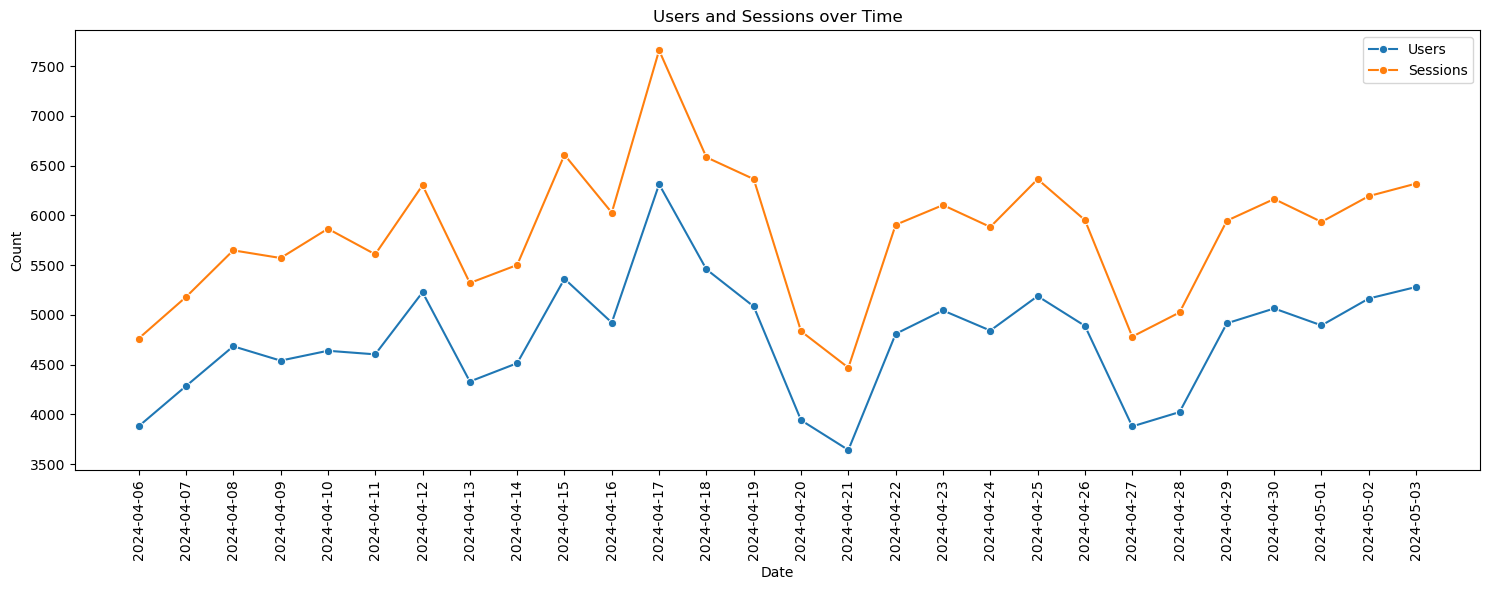

In [141]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'Datehour' is datetime
df["Datehour"] = pd.to_datetime(df["Datehour"], errors="coerce")

# Group data
gp = df.groupby("Datehour").agg({"Users": "sum", "Sessions": "sum"}).reset_index()

# Sort by date just in case
gp = gp.sort_values("Datehour")

# Plot
plt.figure(figsize=(15, 6))
sns.lineplot(data=gp, x="Datehour", y="Users", label="Users",marker = "o")
sns.lineplot(data=gp, x="Datehour", y="Sessions", label="Sessions",marker = "o")

# Force all dates to appear on x-axis
plt.xticks(ticks=gp["Datehour"], rotation=90)

plt.title("Users and Sessions over Time")
plt.xlabel("Date")
plt.ylabel("Count")
plt.tight_layout()
plt.legend()
plt.show()


conclusion : The line plot shows how user activity and session counts vary over time. Both metrics generally follow a similar pattern, indicating a strong correlation between user visits and session frequency. Peaks and drops occur nearly simultaneously, suggesting that as more users visit, session activity also increases. This alignment helps in understanding engagement trends and planning for high-traffic periods.


# Q.2: Find the Total users by Session primary channel group ??

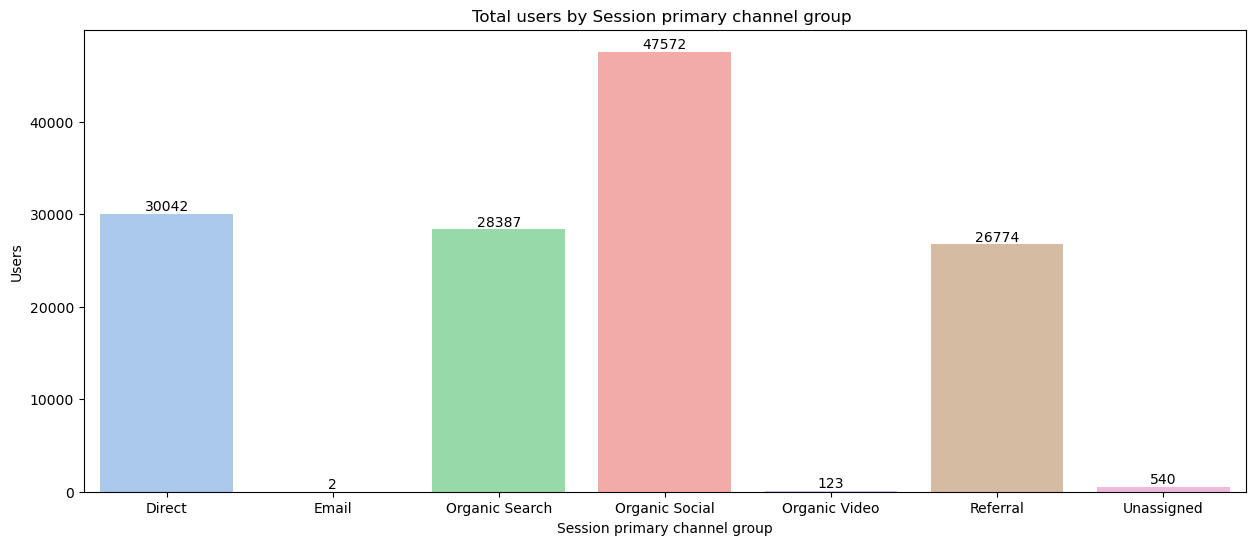

In [183]:
plt.figure(figsize=(15, 6))
gp = df.groupby("Session primary channel group").agg({"Users":"sum"})
c = ['#a1c9f4', '#ffb482', '#8de5a1', '#ff9f9b', '#d0bbff', '#debb9b', '#fab0e4']
a = s.barplot(data = gp,x = "Session primary channel group",y = "Users",palette = c,hue = "Session primary channel group",legend = False)
for bars in a.containers:
    a.bar_label(bars)
plt.title("Total users by Session primary channel group ")
plt.show()


Conclusion : The highest number of users came from Organic Social (47,572), followed by Direct and Organic Search channels.
In contrast, Email, Organic Video, and Unassigned channels contributed minimally to user traffic.

# Q.3 : Find the Total Average engagement time per session by Session primary channel group ??

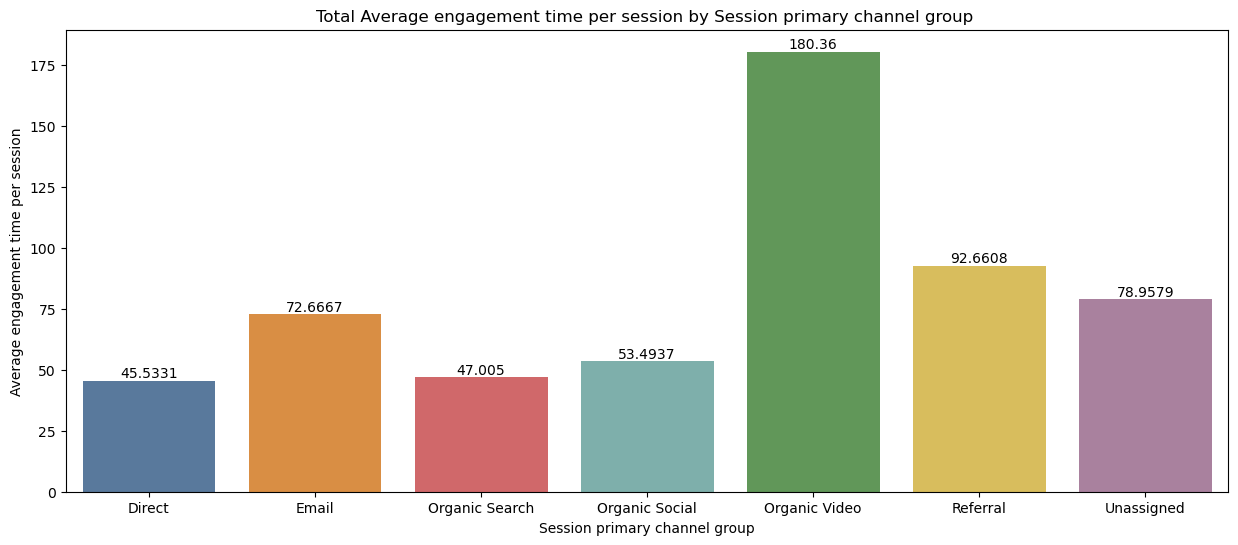

In [202]:
plt.figure(figsize=(15, 6))
gp = df.groupby("Session primary channel group").agg({"Average engagement time per session":"mean"})
c = ['#4E79A7', '#F28E2B', '#E15759', '#76B7B2', '#59A14F', '#EDC948', '#B07AA1']
a = s.barplot(data = gp,x = "Session primary channel group",y = "Average engagement time per session"
              ,palette = c,hue = "Session primary channel group",legend = False)
for bars in a.containers:
    a.bar_label(bars)
plt.title("Total Average engagement time per session by Session primary channel group ")
plt.show()


conclusion : Referral sources have the highest average engagement time per session, indicating highly engaged users.
Organic Social and Organic Search also show good performance with consistent engagement.
Email shows the lowest engagement, suggesting it may need strategic improvement.

# Q.4 : Find the Engagement rate distribution by channel group ??

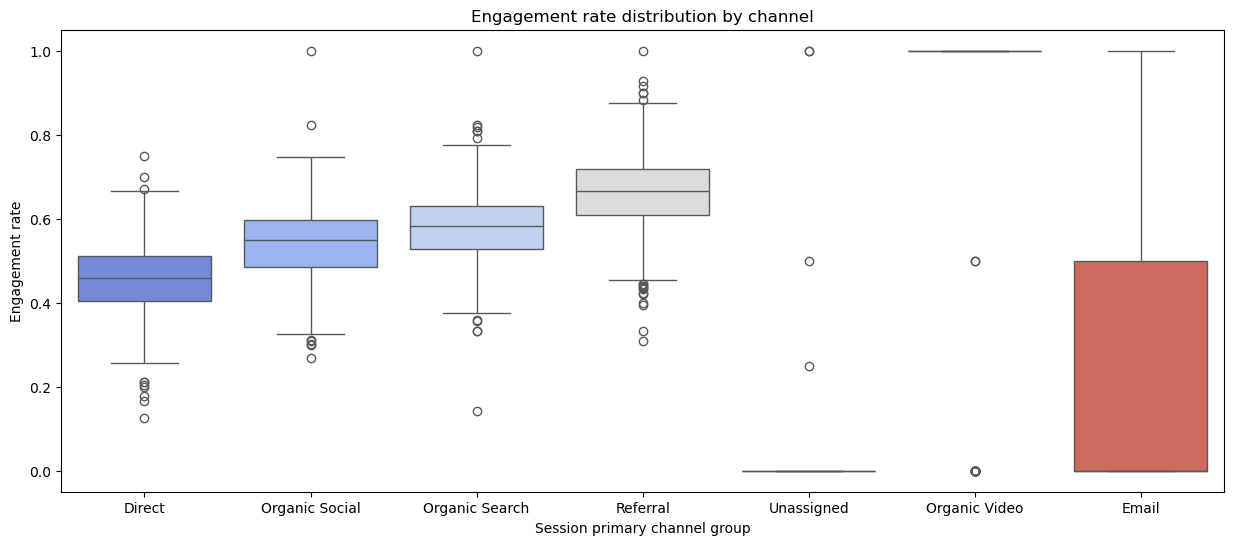

In [216]:
plt.figure(figsize=(15, 6))
s.boxplot(df,x = "Session primary channel group",y = "Engagement rate",palette="coolwarm",hue = "Session primary channel group")
plt.title("Engagement rate distribution by channel")
plt.show()

conclusion :Referral and Organic Search channels have the highest median engagement rates, indicating strong and consistent user interest.
Direct and Organic Social channels also perform fairly well but with wider variation.
Unassigned and Organic Video channels show extremely low or no engagement, highlighting potential issues or misclassification.

# Q.5 : Find Engaged vs Non-Engaged Sessions by Channel Group??

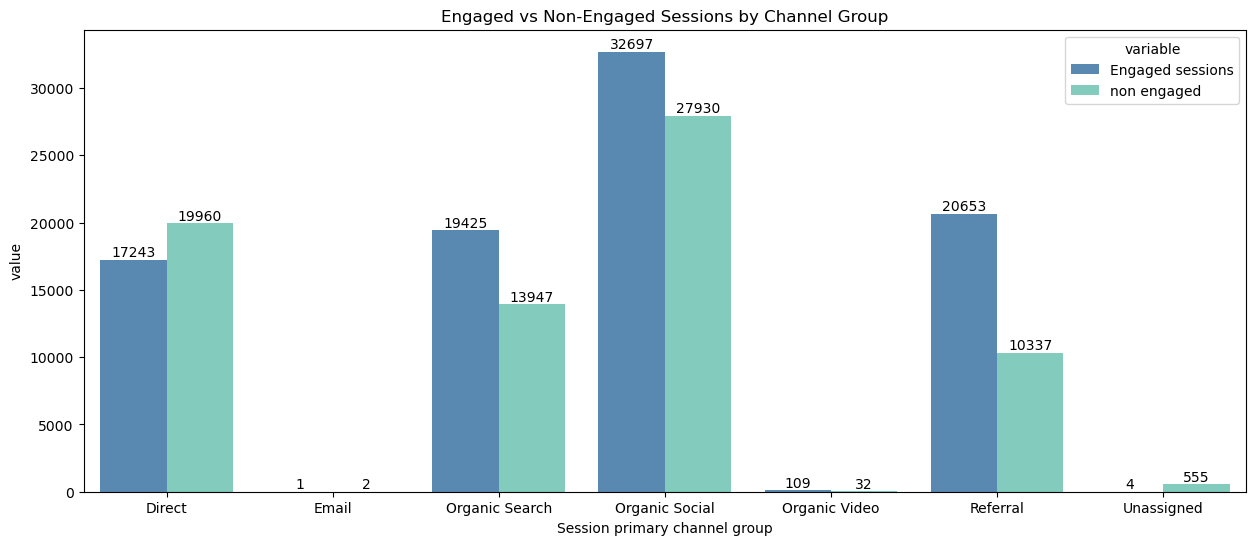

In [262]:
plt.figure(figsize=(15, 6))
gp = df.groupby("Session primary channel group")[["Sessions","Engaged sessions"]].sum().reset_index()
gp["non engaged"] = gp["Sessions"] - gp["Engaged sessions"]
split = gp.melt(id_vars = "Session primary channel group",value_vars = ["Engaged sessions" ,"non engaged"])
cool_colors = ["#4B8BBE", "#76D7C4"]  # Blue and teal
a = s.barplot(split,x = "Session primary channel group" ,y = "value",hue = "variable",palette=cool_colors)
for bars in a.containers:
    a.bar_label(bars)
plt.title("Engaged vs Non-Engaged Sessions by Channel Group")
plt.show()



conclusion : 

1. Organic Social has the highest number of both engaged and non-engaged sessions, showing its overall dominance in session volume.

2. Channels like Referral and Organic Search show significantly higher engaged sessions compared to non-engaged ones, indicating strong user interest.

3. Email and Unassigned channels contribute minimally, suggesting low engagement or traffic from these sources.

# Q.6 : trafic by hous and channel ??

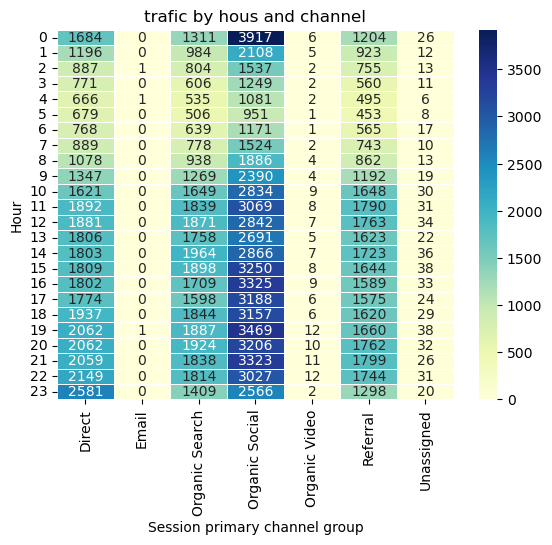

In [284]:
gp = df.groupby(["Hour","Session primary channel group"])["Sessions"].sum().unstack().fillna(0)
s.heatmap(gp,annot = True,fmt = ".0f",cmap="YlGnBu",linewidths = .5)
plt.title("trafic by hous and channel")
plt.show()


conclusion : 

1. Organic Social consistently drives the highest traffic across almost all hours, peaking notably between 15:00 to 18:00.

2. Direct and Organic Search also maintain steady traffic throughout the day, indicating strong direct and search-based engagement.

3. Email and Unassigned channels contribute minimal traffic, suggesting limited reach or user activity through those sources.

# Q.7 Find Engagement rate and Sessions over Time ??


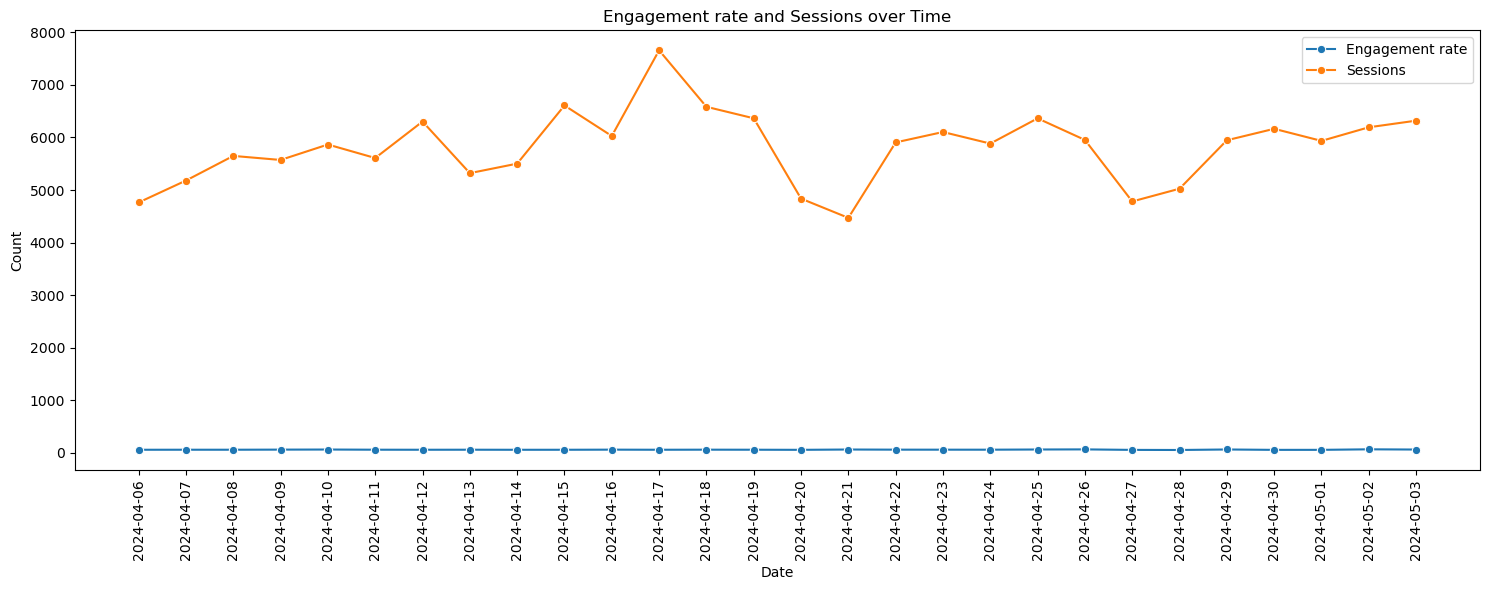

In [292]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'Datehour' is datetime
df["Datehour"] = pd.to_datetime(df["Datehour"], errors="coerce")

# Group data
gp = df.groupby("Datehour").agg({"Engagement rate": "sum", "Sessions": "sum"}).reset_index()

# Sort by date just in case
gp = gp.sort_values("Datehour")

# Plot
plt.figure(figsize=(15, 6))
sns.lineplot(data=gp, x="Datehour", y="Engagement rate", label="Engagement rate",marker = "o")
sns.lineplot(data=gp, x="Datehour", y="Sessions", label="Sessions",marker = "o")

# Force all dates to appear on x-axis
plt.xticks(ticks=gp["Datehour"], rotation=90)

plt.title("Engagement rate and Sessions over Time")
plt.xlabel("Date")
plt.ylabel("Count")
plt.tight_layout()
plt.legend()
plt.show()


conclusion :The number of sessions fluctuated significantly over time, peaking around April 17, 2024.
Despite these fluctuations, the engagement rate remained relatively stable, indicating consistent user interaction quality.

# Final conclusion all the basis of all the graph 

Overall user behavior shows that Organic Social and Direct channels bring the highest volume of users and sessions.
Referral traffic has the highest average engagement time per session, while Email and Unassigned perform the weakest across all metrics.
Engagement rates are consistently higher for Referral and Organic Search, indicating better quality traffic from these sources.
The heatmap reveals peak traffic hours between 11 AM and 6 PM, particularly driven by Organic Social sessions.
Despite variations in session counts over time, engagement rate remains stable, indicating a loyal or consistently interested user base.